# Task 2 — Yelp Polarity Sentiment Classification
**Member:** Tejas · **Seed:** 1446 · DATA266 Lab 1 · Dataset: **Yelp Polarity** (the TA's correction; not IMDB)

Embeddings are learned **from scratch** (`nn.Embedding`, randomly initialized). There are no pretrained vectors or language models.

| Section | Brief item |
|---|---|
| 1 | 2.1 EDA: length and class distribution, malformed entries |
| 2 | 2.1 Preprocessing: lowercase, punctuation/special removal, stopwords (negations kept), lemmatization, tokenization, vocab — cached |
| 3 | Test-set robustness slices |
| 4 | 2.2 Three models: Baseline (fastText-style uni+bigram bag), Exp 1 (Transformer encoder from scratch), Exp 2 (BiGRU + attention pooling) |
| 5 | 2.2 Training with hardware, time, throughput, and memory |
| 6 | 2.2 Full metric suite plus McNemar and slices → `metrics_report.csv` |
| 7 | 2.2.4 Error-review candidates (5 FP / 5 FN / 5 near-threshold / 5 slice) |
| 8 | Full results tables for 2.2 / 2.3 (all metrics, CIs, McNemar, slices, cost, hardware) + consolidated `metrics_report.csv` |

**Team lineup (no shared model families):** Shriram: mean-pool+MLP, BiLSTM (mean+max), TextCNN 2/3/4/5. Tejas: hashed uni+bigram bag, Transformer encoder, BiGRU+attention. Same preprocessing pipeline and identical evaluation code, so the team comparison table lines up.

**Run it from `task2_sentiment/tejas/src/`** (e.g. `../../../.venv/Scripts/jupyter.exe nbconvert --to notebook --execute --inplace task2_sentiment.ipynb`). Everything is saved directly into the repo folders.

**Data:** reads from `task2_sentiment/data/`. Supported layouts: `yelp_review_polarity_csv/{train,test}.csv` (the original release: no header, label 1/2), a saved HF dataset `yelp_polarity_hf/`, or parquet files. Otherwise it downloads `fancyzhx/yelp_polarity` and caches it there.

> **How to read this notebook.** Everything is implemented. Items marked **🔷 DECISION** are choices you should confirm or change (and keep different from your teammate's), then justify in `results.md`. Run top to bottom; `SMOKE=1` runs a tiny end-to-end version.

In [1]:
# One-time setup (uncomment on a fresh machine / Colab). Versions are recorded in the manifest.
# !pip -q install -r ../../../requirements.txt

## 0. Config
### 🔷 DECISIONS
| Decision | Current value | Alternatives | Why |
|---|---|---|---|
| Train size | full 560K (minus 5% val) | subsample | Disclose it if you subsample |
| Stopwords | NLTK English **minus negations** | full list | Dropping "not" flips sentiment |
| Normalization | WordNet lemmatizer (cached per unique word) | Porter stemmer / none | |
| Vocab | min_freq 5, max 50K | | OOV vs. size |
| `max_len` | 95th percentile of train token length (capped at 400) | fixed | Truncation vs. compute |
| Truncation | keep head + tail | head only | Reviews often conclude at the end |
| Baseline | fastText-style: mean of unigram + hashed-bigram embeddings → linear (dim 64, 200K bigram buckets) | mean-pool of unigrams only | Strong, very fast, order-light reference; bigrams capture phrases like 'not good' without a sequence model (Joulin et al. 2016) |
| Exp 1 | Transformer encoder from scratch: 2 layers, 4 heads, d=128, FFN 256, learned positions, pre-LN, masked mean pooling | 1 or 4 layers | Self-attention links any two words directly (e.g. a 'but' clause far from the opinion it reverses) |
| Exp 2 | BiGRU 128 + attention pooling | BiLSTM, final-state pooling | Sequential context; attention weights show which words drive the decision |
| Embedding dim | 64 (baseline) / 128 (Exp 1, Exp 2) | 64–300 | The baseline table has 250K rows, so a smaller dim keeps it compact |
| Threshold | 0.5 | | |
| Slices | length quartile, has negation, has contrast word | | Robustness |

In [2]:
# ── Paths & run mode (no personal paths: everything is relative or env-driven) ──
import os, sys
from pathlib import Path

SMOKE  = os.environ.get("SMOKE", "0") == "1"   # README smoke test: SMOKE=1 jupyter nbconvert --execute ...
MEMBER = "tejas"
SEED   = 1446                                  # last 4 digits of student ID

# Notebook lives in <task>/<member>/src/  ->  member dir is the parent of cwd.
# Fail fast if launched from the wrong folder (e.g. Colab starts in /content) so nothing is written to the wrong place.
if "MEMBER_DIR" not in os.environ and Path.cwd().name != "src":
    raise RuntimeError(
        f"Working directory is {Path.cwd()} — expected <repo>/<task>/<member>/src.\n"
        "Colab: run the 'Colab setup' cell above (mount Drive + %cd into src/) first. "
        "Elsewhere: cd into the src/ folder, or set the MEMBER_DIR environment variable.")
MEMBER_DIR = Path(os.environ.get("MEMBER_DIR", Path.cwd().parent)).resolve()
TASK_DIR   = MEMBER_DIR.parent
REPO_ROOT  = TASK_DIR.parent
DATA_DIR   = Path(os.environ.get("DATA_DIR", TASK_DIR / "data")).resolve()

CKPT_DIR   = MEMBER_DIR / "checkpoints"
OUT_DIR    = MEMBER_DIR / "outputs"
PROC_DIR   = MEMBER_DIR / "data_processed"
LOG_DIR    = REPO_ROOT / "reproducibility" / "raw_logs" / TASK_DIR.name / MEMBER
MANI_DIR   = REPO_ROOT / "reproducibility" / "manifests" / TASK_DIR.name / MEMBER
assert TASK_DIR.name.startswith("task"), f"Unexpected layout: TASK_DIR={TASK_DIR}"
for d in (CKPT_DIR, OUT_DIR, PROC_DIR, LOG_DIR, MANI_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"SMOKE={SMOKE}  MEMBER_DIR={MEMBER_DIR}\nDATA_DIR={DATA_DIR}")

SMOKE=False  MEMBER_DIR=<REPO>\task2_sentiment\tejas
DATA_DIR=<REPO>\task2_sentiment\data


In [3]:
CFG = dict(
    run_name="t2_sentiment_" + MEMBER,
    train_subset=None,              # 🔷 None = full training set
    val_frac=0.05,                  # 🔷
    keep_negations=True,            # 🔷
    normalizer="lemma",             # 🔷 "lemma" | "stem" | "none"
    min_freq=5, max_vocab=50_000,   # 🔷
    max_len_pct=95, max_len_cap=400,# 🔷
    truncation="head_tail",         # 🔷 "head" | "head_tail"
    threshold=0.5,
    n_bootstrap=1000,
    ece_bins=15,
    patience=2,
    log_every=200,
    grad_clip=5.0,
    models={                        # 🔷 must differ from your teammate's lineup
        "baseline": dict(arch="ngram_bag",   emb_dim=64,  lr=2e-3, batch_size=256, epochs=5, dropout=0.2,
                         n_buckets=200_000),
        "exp1":     dict(arch="transformer", emb_dim=128, lr=5e-4, batch_size=128, epochs=5, dropout=0.1,
                         n_heads=4, n_layers=2, ff_dim=256),
        "exp2":     dict(arch="bigru",       emb_dim=128, lr=1e-3, batch_size=128, epochs=5, dropout=0.3,
                         hidden=128, attn_pool=True),
    },
    review_model="best",            # 🔷 "best" = model with the highest test macro-F1, or a model name
)
if SMOKE:
    CFG.update(train_subset=3000, n_bootstrap=50, log_every=10, min_freq=2)
    for m in CFG["models"].values():
        m.update(epochs=2, batch_size=64)
CFG

{'run_name': 't2_sentiment_tejas',
 'train_subset': None,
 'val_frac': 0.05,
 'keep_negations': True,
 'normalizer': 'lemma',
 'min_freq': 5,
 'max_vocab': 50000,
 'max_len_pct': 95,
 'max_len_cap': 400,
 'truncation': 'head_tail',
 'threshold': 0.5,
 'n_bootstrap': 1000,
 'ece_bins': 15,
 'patience': 2,
 'log_every': 200,
 'grad_clip': 5.0,
 'models': {'baseline': {'arch': 'ngram_bag',
   'emb_dim': 64,
   'lr': 0.002,
   'batch_size': 256,
   'epochs': 5,
   'dropout': 0.2,
   'n_buckets': 200000},
  'exp1': {'arch': 'transformer',
   'emb_dim': 128,
   'lr': 0.0005,
   'batch_size': 128,
   'epochs': 5,
   'dropout': 0.1,
   'n_heads': 4,
   'n_layers': 2,
   'ff_dim': 256},
  'exp2': {'arch': 'bigru',
   'emb_dim': 128,
   'lr': 0.001,
   'batch_size': 128,
   'epochs': 5,
   'dropout': 0.3,
   'hidden': 128,
   'attn_pool': True}},
 'review_model': 'best'}

In [4]:
# ── Plumbing utilities (implemented — not model logic) ──
import sys, json, time, math, random, platform, subprocess
import numpy as np
import torch

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def get_device() -> torch.device:
    if torch.cuda.is_available():         return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

def cpu_model() -> str:
    """Exact CPU model name (the brief asks for the exact CPU/GPU)."""
    try:
        if sys.platform == "win32":
            import winreg
            k = winreg.OpenKey(winreg.HKEY_LOCAL_MACHINE, r"HARDWARE\DESCRIPTION\System\CentralProcessor\0")
            return winreg.QueryValueEx(k, "ProcessorNameString")[0].strip()
        if sys.platform == "darwin":
            return subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True).stdout.strip()
        with open("/proc/cpuinfo") as f:
            for line in f:
                if line.startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or platform.machine()

def hardware_info(device) -> dict:
    info = {"platform": platform.platform(), "python": platform.python_version(),
            "torch": torch.__version__, "device": str(device),
            "cpu": cpu_model(), "cpu_count": os.cpu_count()}
    if device.type == "cuda":
        p = torch.cuda.get_device_properties(0)
        info.update(gpu=p.name, gpu_mem_gb=round(p.total_memory / 1e9, 2), cuda=torch.version.cuda)
    elif device.type == "mps":
        info.update(gpu="Apple Silicon GPU (MPS)")
    return info

class PeakMemory:
    """CUDA: true peak. MPS/CPU: sample() periodically and keep the max seen."""
    def __init__(self, device):
        self.device, self.max_mb = device, 0.0
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
    def sample(self) -> float:
        if self.device.type == "cuda":
            cur = torch.cuda.max_memory_allocated() / 2**20
        elif self.device.type == "mps":
            cur = torch.mps.driver_allocated_memory() / 2**20
        else:
            try:
                import resource                      # Unix only
                r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
                cur = r / 2**20 if sys.platform == "darwin" else r / 2**10
            except ImportError:
                cur = float("nan")
        self.max_mb = max(self.max_mb, cur)
        return self.max_mb

class RunLogger:
    """Append-only JSONL raw log. Evidence trail — never edit after the run."""
    def __init__(self, run_name: str):
        self.path = LOG_DIR / f"{run_name}_{time.strftime('%Y%m%d-%H%M%S')}.jsonl"
        self.f = open(self.path, "a", buffering=1)
        print("Raw log ->", self.path)
    def log(self, **kw):
        kw["wall_time"] = time.time()
        self.f.write(json.dumps(kw, default=float) + "\n")
    def close(self):
        self.f.close()

def read_log(path) -> list:
    with open(path) as f:
        return [json.loads(line) for line in f]

def save_checkpoint(path, **state):
    """Atomic save so a disconnect mid-write can't corrupt the checkpoint."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(".tmp"); torch.save(state, tmp); os.replace(tmp, path)

def load_checkpoint(path, device):
    path = Path(path)
    return torch.load(path, map_location=device, weights_only=False) if path.exists() else None

def count_params(model) -> int:
    return sum(p.numel() for p in model.parameters())

def write_manifest(cfg: dict, device, extra: dict = None):
    freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
    (MANI_DIR / "requirements_frozen.txt").write_text(freeze)
    manifest = {"run_name": cfg["run_name"], "seed": SEED, "smoke": SMOKE, "config": cfg,
                "hardware": hardware_info(device), "created": time.strftime("%Y-%m-%d %H:%M:%S"),
                **(extra or {})}
    p = MANI_DIR / f"manifest_{cfg['run_name']}.json"
    p.write_text(json.dumps(manifest, indent=2, default=str))
    print("Manifest ->", p)

def write_metrics_csv(rows: list, path):
    import pandas as pd
    pd.DataFrame(rows).to_csv(path, index=False)
    print("Metrics ->", path)

set_seed(SEED)
DEVICE = get_device()
print(json.dumps(hardware_info(DEVICE), indent=2))

{
  "platform": "Windows-11-10.0.26200-SP0",
  "python": "3.12.10",
  "torch": "2.14.1+cu126",
  "device": "cuda",
  "cpu": "AMD Ryzen 9 7950X 16-Core Processor",
  "cpu_count": 32,
  "gpu": "NVIDIA GeForce RTX 4090",
  "gpu_mem_gb": 25.76,
  "cuda": "12.6"
}


## 1. Load data and EDA (2.1)

In [5]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def _load_raw():
    csv_dir = DATA_DIR / "yelp_review_polarity_csv"
    if (csv_dir / "train.csv").exists():
        tr = pd.read_csv(csv_dir / "train.csv", header=None, names=["label", "text"])
        te = pd.read_csv(csv_dir / "test.csv",  header=None, names=["label", "text"])
        return tr, te
    hf = DATA_DIR / "yelp_polarity_hf"
    if hf.exists():
        from datasets import load_from_disk
        ds = load_from_disk(str(hf))
        return ds["train"].to_pandas(), ds["test"].to_pandas()
    pq_tr = sorted(glob.glob(str(DATA_DIR / "**" / "train*.parquet"), recursive=True))
    pq_te = sorted(glob.glob(str(DATA_DIR / "**" / "test*.parquet"), recursive=True))
    if pq_tr and pq_te:
        return pd.concat(map(pd.read_parquet, pq_tr)), pd.concat(map(pd.read_parquet, pq_te))
    from datasets import load_dataset
    ds = load_dataset("fancyzhx/yelp_polarity")
    ds.save_to_disk(str(hf))
    return ds["train"].to_pandas(), ds["test"].to_pandas()

def _normalize_labels(df):
    df = df[["text", "label"]].copy()
    labs = set(pd.unique(df["label"].dropna()))
    if labs <= {1, 2}:
        df["label"] = df["label"].map({1: 0, 2: 1})        # original release: 1 = negative, 2 = positive
    return df

def clean_malformed(df, name):
    n0 = len(df)
    df = df.dropna(subset=["text", "label"])
    df = df[df["text"].astype(str).str.strip().str.len() > 0]
    df = df[df["label"].isin([0, 1])]
    n1 = len(df)
    df = df.drop_duplicates(subset=["text"])
    rep = {"split": name, "rows_in": n0, "dropped_missing_or_empty_or_badlabel": n0 - n1, "dropped_duplicates": n1 - len(df), "rows_out": len(df)}
    return df.reset_index(drop=True).astype({"label": int, "text": str}), rep

raw_tr, raw_te = _load_raw()
raw_tr, raw_te = _normalize_labels(raw_tr), _normalize_labels(raw_te)
train_full, rep_tr = clean_malformed(raw_tr, "train")
test_df, rep_te = clean_malformed(raw_te, "test")
if CFG["train_subset"] and CFG["train_subset"] < len(train_full):
    train_full, _ = train_test_split(train_full, train_size=CFG["train_subset"], stratify=train_full["label"], random_state=SEED)
train_df, val_df = train_test_split(train_full, test_size=CFG["val_frac"], stratify=train_full["label"], random_state=SEED)
train_df, val_df = train_df.reset_index(drop=True), val_df.reset_index(drop=True)
MALFORMED = pd.DataFrame([rep_tr, rep_te]); display(MALFORMED)
print("Label check -> negative example:", train_df[train_df.label == 0].text.iloc[0][:150])
print("               positive example:", train_df[train_df.label == 1].text.iloc[0][:150])

README.md:   0%|          | 0.00/8.93k [00:00<?, ?B/s]

<REPO>\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in <HOME>\.cache\huggingface\hub\datasets--fancyzhx--yelp_polarity. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


<REPO>\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in <HOME>\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  256MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/560000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/38000 [00:00<?, ? examples/s]

,split,rows_in,dropped_missing_or_empty_or_badlabel,dropped_duplicates,rows_out
0,train,560000,0,0,560000
1,test,38000,0,0,38000


Label check -> negative example: I've been here several times and always recommended this steak house to fellow coworkers and clients because I love Michael Mina restaurants. The qual
               positive example: Excellent food especially the garlic name bread. Good service, we ordered the bharta bruchetta appetizer which was good and they didn't bring out our 


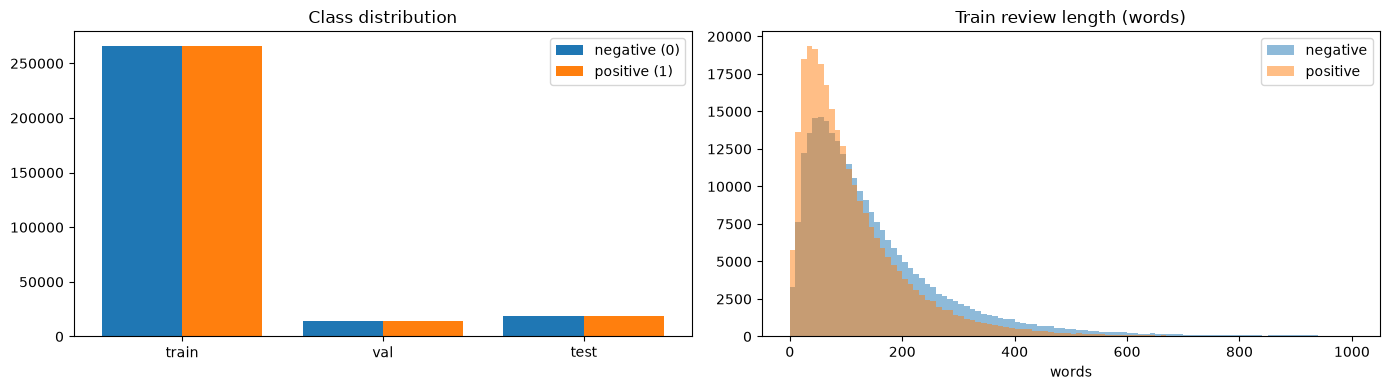

,n,pos_frac,len_mean,len_median,len_p95,len_max
train,532000.0,0.5,133.0,97.0,372.0,1052.0
val,28000.0,0.5,133.0,97.0,370.0,977.0
test,38000.0,0.5,132.6,97.0,367.0,1007.0


In [6]:
def eda(dfs: dict) -> dict:
    summary = {}
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    names = list(dfs)
    neg = [int((dfs[n].label == 0).sum()) for n in names]; pos = [int((dfs[n].label == 1).sum()) for n in names]
    x = np.arange(len(names))
    ax[0].bar(x - 0.2, neg, 0.4, label="negative (0)"); ax[0].bar(x + 0.2, pos, 0.4, label="positive (1)")
    ax[0].set_xticks(x, names); ax[0].set_title("Class distribution"); ax[0].legend()
    lens = dfs["train"].text.str.split().str.len()
    for lab, name in ((0, "negative"), (1, "positive")):
        ax[1].hist(lens[dfs["train"].label == lab], bins=100, range=(0, 1000), alpha=0.5, label=name)
    ax[1].set_title("Train review length (words)"); ax[1].set_xlabel("words"); ax[1].legend()
    plt.tight_layout(); plt.savefig(OUT_DIR / "eda_class_and_length.png", dpi=150); plt.show()
    for n in names:
        l = dfs[n].text.str.split().str.len()
        summary[n] = {"n": len(dfs[n]), "pos_frac": round(float(dfs[n].label.mean()), 4),
                      "len_mean": round(float(l.mean()), 1), "len_median": float(l.median()),
                      "len_p95": float(l.quantile(0.95)), "len_max": int(l.max())}
    return summary

EDA = eda({"train": train_df, "val": val_df, "test": test_df})
pd.DataFrame(EDA).T

## 2. Preprocessing, tokenization, and vocab (2.1) — cached to `data_processed/`
Lemmatization runs once per *unique* word rather than per occurrence, which makes 560K reviews take minutes instead of hours.

In [7]:
import re, collections, html
import nltk
for pkg in ("stopwords", "wordnet", "omw-1.4"):
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

NEGATIONS = {"no", "not", "nor", "never", "none", "nothing", "nobody", "neither", "nowhere", "cannot",
             "don", "didn", "doesn", "isn", "wasn", "weren", "won", "wouldn", "shouldn", "couldn", "aren", "hasn", "haven", "hadn", "ain"}
STOP = set(nltk_stopwords.words("english"))
if CFG["keep_negations"]:
    STOP -= NEGATIONS

_re_url = re.compile(r"https?://\S+|www\.\S+")
_re_nt  = re.compile(r"n't\b")
_re_bad = re.compile(r"[^a-z\s]")

def clean_tokens(text: str) -> list:
    t = html.unescape(text).replace("\\n", " ").replace('\\"', '"').lower()
    t = _re_url.sub(" ", t)
    t = t.replace("can't", "can not").replace("won't", "will not")
    t = _re_nt.sub(" not", t)                     # negation contractions -> "not" before punctuation removal
    t = _re_bad.sub(" ", t)                       # punctuation, digits, special characters
    return [w for w in t.split() if (w not in STOP and len(w) > 1) or (CFG["keep_negations"] and w in NEGATIONS)]

def normalize(token_lists, how: str):
    if how == "none":
        return token_lists
    uniq = {w for toks in token_lists for w in toks}
    if how == "lemma":
        lem = WordNetLemmatizer(); m = {w: lem.lemmatize(lem.lemmatize(w), pos="v") for w in uniq}
    else:
        st = PorterStemmer(); m = {w: st.stem(w) for w in uniq}
    return [[m[w] for w in toks] for toks in token_lists]

def build_vocab(token_lists, min_freq, max_vocab):
    c = collections.Counter(w for toks in token_lists for w in toks)
    vocab = {"<pad>": 0, "<unk>": 1}
    for w, n in c.most_common(max_vocab - 2):
        if n < min_freq:
            break
        vocab[w] = len(vocab)
    return vocab

def encode_pad(token_lists, vocab, max_len, truncation):
    ids = np.zeros((len(token_lists), max_len), dtype=np.int32); lens = np.zeros(len(token_lists), dtype=np.int64)
    for i, toks in enumerate(token_lists):
        seq = [vocab.get(w, 1) for w in toks]
        if len(seq) > max_len:
            seq = seq[:max_len] if truncation == "head" else seq[:max_len // 2] + seq[-(max_len - max_len // 2):]
        if not seq:
            seq = [1]
        ids[i, :len(seq)] = seq; lens[i] = len(seq)
    return torch.from_numpy(ids), torch.from_numpy(lens)

import hashlib
_prep_keys = ("train_subset", "val_frac", "keep_negations", "normalizer", "min_freq", "max_vocab", "max_len_pct", "max_len_cap", "truncation")
_prep_sig = hashlib.md5(json.dumps({k: CFG[k] for k in _prep_keys} | {"seed": SEED}, sort_keys=True).encode()).hexdigest()[:8]
cache = PROC_DIR / f"processed_{'smoke' if SMOKE else 'full'}_{_prep_sig}.pt"   # new file whenever a preprocessing setting changes
if cache.exists():
    P = torch.load(cache, weights_only=False); print("Loaded cached preprocessing:", cache)
else:
    t0 = time.time()
    toks = {n: normalize([clean_tokens(t) for t in df.text.tolist()], CFG["normalizer"])
            for n, df in (("train", train_df), ("val", val_df), ("test", test_df))}
    vocab = build_vocab(toks["train"], CFG["min_freq"], CFG["max_vocab"])   # train only
    tok_lens = np.array([len(t) for t in toks["train"]])
    max_len = int(min(CFG["max_len_cap"], np.percentile(tok_lens, CFG["max_len_pct"])))
    P = {"vocab": vocab, "max_len": max_len, "test_raw_text": test_df.text.tolist(), "test_tokens": toks["test"],
         "prep_time_s": time.time() - t0}
    for n, df in (("train", train_df), ("val", val_df), ("test", test_df)):
        ids, lens = encode_pad(toks[n], vocab, max_len, CFG["truncation"])
        P[n] = (ids, lens, torch.tensor(df.label.values, dtype=torch.float32))
    torch.save(P, cache)
    print(f"Preprocessed in {P['prep_time_s']/60:.1f} min -> {cache}")
VOCAB_SIZE, MAX_LEN = len(P["vocab"]), P["max_len"]
oov = (P["test"][0] == 1).sum().item() / P["test"][1].sum().item()
print(f"vocab={VOCAB_SIZE:,}  max_len={MAX_LEN}  test OOV rate={oov:.4f}")
print("example:", test_df.text.iloc[0][:120], "\n  ->", P["test_tokens"][0][:25])

Preprocessed in 0.6 min -> <REPO>\task2_sentiment\tejas\data_processed\processed_full_7c67c415.pt
vocab=45,818  max_len=188  test OOV rate=0.0055
example: Contrary to other reviews, I have zero complaints about the service or the prices. I have been getting tire service here 
  -> ['contrary', 'review', 'zero', 'complaint', 'service', 'price', 'get', 'tire', 'service', 'past', 'year', 'compare', 'experience', 'place', 'like', 'pep', 'boy', 'guy', 'experience', 'know', 'also', 'one', 'place', 'not', 'feel']


## 3. Robustness slices (test set)

In [8]:
_re_contrast = re.compile(r"\b(but|however|although|though|yet)\b", re.I)
_re_neg = re.compile(r"\b(not|no|never|n't|nothing|none)\b|n't", re.I)

def make_slices(raw_texts, token_lists) -> pd.DataFrame:
    wlen = np.array([len(t.split()) for t in raw_texts])
    q = np.quantile(wlen, [0.25, 0.5, 0.75])
    bucket = np.select([wlen <= q[0], wlen <= q[1], wlen <= q[2]], ["Q1_short", "Q2", "Q3"], "Q4_long")
    return pd.DataFrame({"length_bucket": bucket,
                         "has_negation": [bool(_re_neg.search(t)) for t in raw_texts],
                         "has_contrast": [bool(_re_contrast.search(t)) for t in raw_texts],
                         "truncated": [len(t) > MAX_LEN for t in token_lists]})

SLICES = make_slices(P["test_raw_text"], P["test_tokens"])
pd.concat({c: SLICES[c].astype(str).value_counts() for c in SLICES.columns}).rename("n").to_frame()

n
length_bucket Q1_short   9590
              Q3         9502
              Q4_long    9458
              Q2         9450
has_negation  True      28247
              False      9753
has_contrast  True      22365
              False     15635
truncated     False     36157
              True       1843

## 4. Models: embeddings learned from scratch (2.2)

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class NGramBagClassifier(nn.Module):
    """Baseline (fastText-style): mean of unigram embeddings and hashed-bigram embeddings -> linear.
    Bigram (a, b) -> bucket (a * 1_000_003 + b) mod n_buckets, stored after the V unigram rows. Order only enters through bigrams."""
    def __init__(self, vocab_size, emb_dim, dropout, n_buckets=200_000, **_):
        super().__init__()
        self.V, self.nb = vocab_size, n_buckets
        self.emb = nn.Embedding(vocab_size + n_buckets, emb_dim, padding_idx=0)
        self.drop = nn.Dropout(dropout); self.fc = nn.Linear(emb_dim, 1)
    def forward(self, ids, lengths):
        a, b = ids[:, :-1], ids[:, 1:]
        bi = (a * 1_000_003 + b) % self.nb + self.V
        bi = bi.masked_fill((a == 0) | (b == 0), 0)                        # no bigrams touching padding
        allids = torch.cat([ids, bi], dim=1)
        e = self.emb(allids); m = (allids != 0).unsqueeze(-1).float()
        pooled = (e * m).sum(1) / m.sum(1).clamp(min=1)
        return self.fc(self.drop(pooled)).squeeze(-1)

class TransformerClassifier(nn.Module):
    """Small Transformer encoder trained from scratch (no pretrained weights): token + learned positional embeddings,
    pre-LN encoder layers, masked mean pooling over real tokens -> linear."""
    def __init__(self, vocab_size, emb_dim, dropout, n_heads=4, n_layers=2, ff_dim=256, max_len=512, **_):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.pos = nn.Embedding(max_len, emb_dim)
        layer = nn.TransformerEncoderLayer(emb_dim, n_heads, ff_dim, dropout, activation="gelu", batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(layer, n_layers, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(emb_dim); self.drop = nn.Dropout(dropout); self.fc = nn.Linear(emb_dim, 1)
    def forward(self, ids, lengths):
        pad = ids == 0                                                         # every row has >= 1 real token
        pos = torch.arange(ids.size(1), device=ids.device)
        h = self.norm(self.enc(self.drop(self.emb(ids) + self.pos(pos)), src_key_padding_mask=pad))
        m = (~pad).unsqueeze(-1).float()
        return self.fc(self.drop((h * m).sum(1) / m.sum(1).clamp(min=1))).squeeze(-1)

class BiGRUClassifier(nn.Module):
    """Bidirectional GRU over packed sequences, then attention pooling (or final states)."""
    def __init__(self, vocab_size, emb_dim, dropout, hidden=128, attn_pool=True, **_):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.attn_pool = attn_pool; self.score = nn.Linear(2 * hidden, 1)
        self.drop = nn.Dropout(dropout); self.fc = nn.Linear(2 * hidden, 1)
    def forward(self, ids, lengths):
        e = self.drop(self.emb(ids))
        packed = nn.utils.rnn.pack_padded_sequence(e, lengths.clamp(min=1).cpu(), batch_first=True, enforce_sorted=False)
        out, h = self.gru(packed)
        if self.attn_pool:
            H, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=ids.size(1))   # (B, L, 2h)
            s = self.score(H).squeeze(-1).masked_fill(ids == 0, float("-inf"))
            pooled = (F.softmax(s, dim=1).unsqueeze(-1) * H).sum(1)
        else:
            pooled = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.drop(pooled)).squeeze(-1)

ARCHS = {"ngram_bag": NGramBagClassifier, "transformer": TransformerClassifier, "bigru": BiGRUClassifier}

## 5. Training (2.2): hardware, time, throughput, and memory recorded per model
Each model saves `outputs/<name>_test_probs.npy`. All metrics are computed from these files, so they can be recomputed on any machine without retraining.

In [10]:
from torch.utils.data import TensorDataset, DataLoader

def _sync():
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    elif DEVICE.type == "mps": torch.mps.synchronize()

@torch.no_grad()
def predict_proba(model, loader) -> np.ndarray:
    model.eval(); out = []
    for ids, lens, _ in loader:
        out.append(torch.sigmoid(model(ids.to(DEVICE).long(), lens.to(DEVICE))).float().cpu())
    model.train()
    return torch.cat(out).numpy()

def _macro_f1(y, p, thr):
    from sklearn.metrics import f1_score
    return f1_score(y, (p >= thr).astype(int), average="macro")

def train_one(name: str, mcfg: dict) -> dict:
    set_seed(SEED)
    model = ARCHS[mcfg["arch"]](VOCAB_SIZE, max_len=MAX_LEN, **mcfg).to(DEVICE)
    g = torch.Generator().manual_seed(SEED)
    tr_loader = DataLoader(TensorDataset(*P["train"]), batch_size=mcfg["batch_size"], shuffle=True, generator=g, drop_last=True)
    va_loader = DataLoader(TensorDataset(*P["val"]),  batch_size=512)
    te_loader = DataLoader(TensorDataset(*P["test"]), batch_size=512)
    opt = torch.optim.Adam(model.parameters(), lr=mcfg["lr"])
    loss_fn = nn.BCEWithLogitsLoss()
    logger, mem = RunLogger(f"{CFG['run_name']}_{name}"), PeakMemory(DEVICE)
    logger.log(event="start", model=name, cfg=mcfg, n_params=count_params(model), hardware=hardware_info(DEVICE))
    best_f1, bad_epochs, step, train_time, n_seen = -1.0, 0, 0, 0.0, 0
    y_val = P["val"][2].numpy()
    for epoch in range(mcfg["epochs"]):
        model.train(); t_ep = time.time(); ep_seen = 0
        for ids, lens, y in tr_loader:
            ids, lens, y = ids.to(DEVICE).long(), lens.to(DEVICE), y.to(DEVICE)
            loss = loss_fn(model(ids, lens), y)
            opt.zero_grad(set_to_none=True); loss.backward()
            gn = torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"]).item()
            opt.step(); step += 1; ep_seen += len(y)
            if step % CFG["log_every"] == 0:
                logger.log(step=step, epoch=epoch, train_loss=loss.item(), grad_norm=gn, peak_mem_mb=mem.sample())
        _sync(); dt = time.time() - t_ep; train_time += dt; n_seen += ep_seen
        vp = predict_proba(model, va_loader); vf1 = _macro_f1(y_val, vp, CFG["threshold"])
        logger.log(event="epoch", epoch=epoch, val_macro_f1=vf1, epoch_time_s=dt, ex_per_sec=ep_seen / dt, peak_mem_mb=mem.sample())
        print(f"[{name}] epoch {epoch}  val macro-F1 {vf1:.4f}  {ep_seen/dt:,.0f} ex/s  {dt:.0f}s")
        if vf1 > best_f1:
            best_f1, bad_epochs = vf1, 0
            save_checkpoint(CKPT_DIR / f"{name}_best.pt", model=model.state_dict(), cfg=mcfg, vocab_size=VOCAB_SIZE, epoch=epoch, val_macro_f1=vf1)
        else:
            bad_epochs += 1
            if bad_epochs >= CFG["patience"]:
                print(f"[{name}] early stop"); break
    model.load_state_dict(load_checkpoint(CKPT_DIR / f"{name}_best.pt", DEVICE)["model"])
    test_probs = predict_proba(model, te_loader)
    np.save(OUT_DIR / f"{name}_test_probs.npy", test_probs)
    res = {"name": name, "test_probs": test_probs, "param_count": count_params(model), "train_time_s": train_time,
           "ex_per_sec": n_seen / train_time, "peak_mem_mb": mem.sample(), "hardware": hardware_info(DEVICE),
           "best_val_macro_f1": best_f1, "log_path": str(logger.path)}
    logger.log(event="done", **{k: v for k, v in res.items() if k != "test_probs"}); logger.close()
    return res

RESULTS = {}
for name, mcfg in CFG["models"].items():
    print(f"\n=== {name}: {mcfg['arch']} ===")
    RESULTS[name] = train_one(name, mcfg)
Y_TEST = P["test"][2].numpy().astype(int)


=== baseline: ngram_bag ===


Raw log -> <REPO>\reproducibility\raw_logs\task2_sentiment\tejas\t2_sentiment_tejas_baseline_20261001-154517.jsonl


[baseline] epoch 0  val macro-F1 0.9273  78,056 ex/s  7s


[baseline] epoch 1  val macro-F1 0.9306  86,901 ex/s  6s


[baseline] epoch 2  val macro-F1 0.9312  80,180 ex/s  7s


...

[exp2] epoch 0  val macro-F1 0.9435  3,622 ex/s  147s


[exp2] epoch 1  val macro-F1 0.9493  3,601 ex/s  148s


[exp2] epoch 2  val macro-F1 0.9527  3,526 ex/s  151s


[exp2] epoch 3  val macro-F1 0.9502  3,865 ex/s  138s


[exp2] epoch 4  val macro-F1 0.9524  3,909 ex/s  136s
[exp2] early stop


## 6. Full metric suite (2.2 / 2.3)

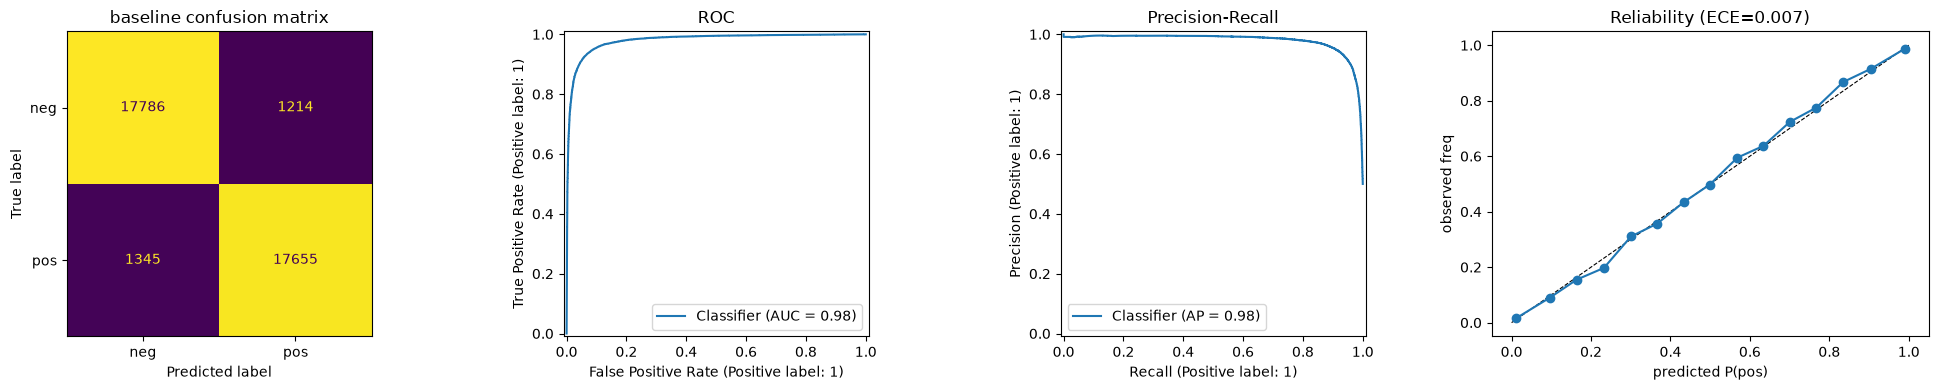

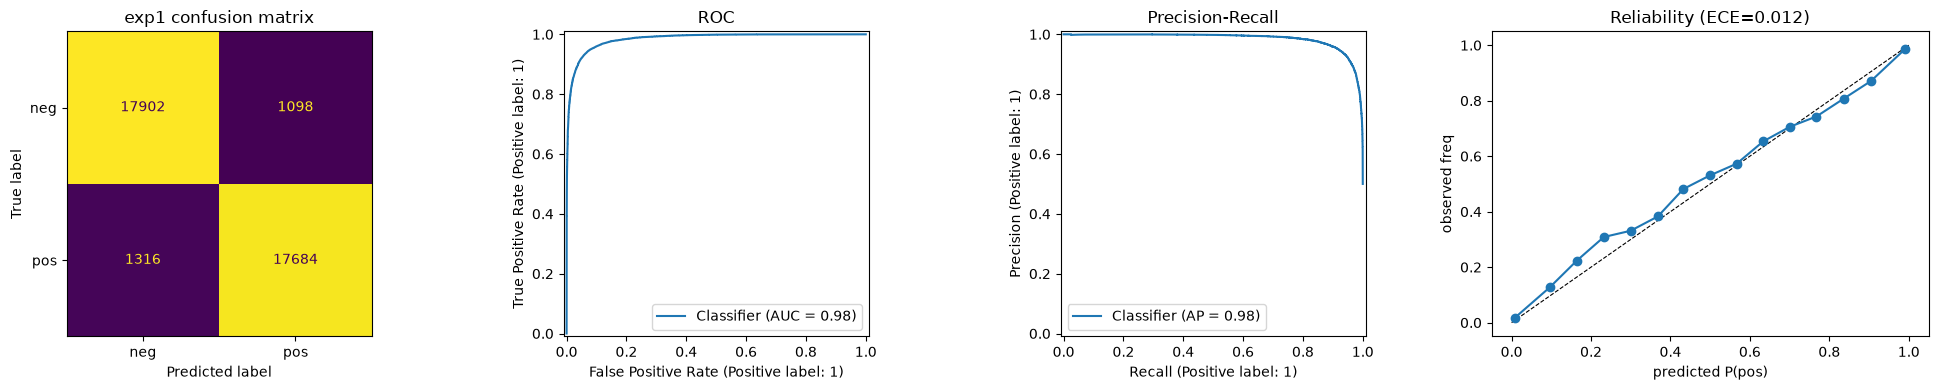

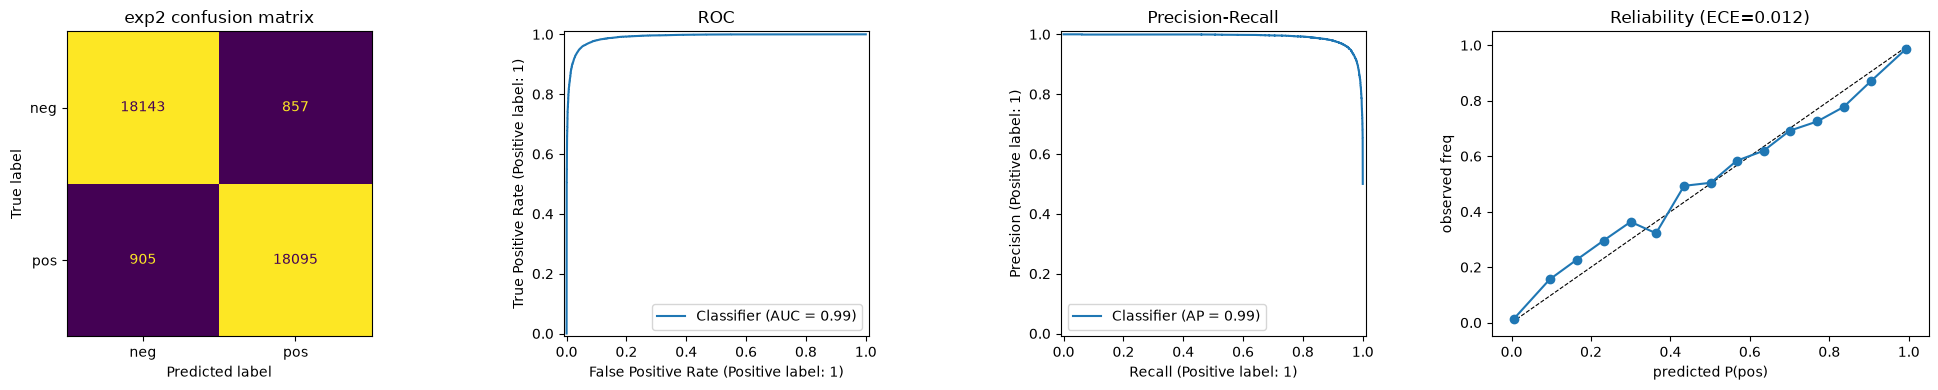

Metrics -> <REPO>\task2_sentiment\tejas\metrics_report.csv


Manifest -> <REPO>\reproducibility\manifests\task2_sentiment\tejas\manifest_t2_sentiment_tejas.json


,model,arch,accuracy,f1_macro,roc_auc,pr_auc,mcc,brier,ece,param_count,train_time_min,examples_per_sec
0,baseline,ngram_bag,0.9327,0.9327,0.9794,0.9788,0.8653,0.0507,0.0072,15732417,0.5513,80405.3045
1,exp1,transformer,0.9365,0.9365,0.9843,0.9847,0.8730,0.0477,0.0121,6154113,2.9654,14949.5341
2,exp2,bigru,0.9536,0.9536,0.9906,0.9909,0.9073,0.0356,0.0120,6063362,11.9869,3698.2555


model                   baseline    exp1    exp2
slice         value                             
has_contrast  False       0.9420  0.9479  0.9599
              True        0.9245  0.9271  0.9482
has_negation  False       0.9239  0.9315  0.9389
              True        0.9259  0.9293  0.9513
length_bucket Q1_short    0.9293  0.9345  0.9473
              Q2          0.9329  0.9353  0.9571
              Q3          0.9335  0.9353  0.9564
              Q4_long     0.9280  0.9349  0.9487
truncated     False       0.9332  0.9368  0.9544
              True        0.9111  0.9219  0.9294

In [11]:
from sklearn import metrics as skm
from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar

def expected_calibration_error(y, p, n_bins=15):
    pred = (p >= 0.5).astype(int); conf = np.where(pred == 1, p, 1 - p); correct = (pred == y).astype(float)
    edges = np.linspace(0.5, 1.0, n_bins + 1); ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi) if lo > 0.5 else (conf >= lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(ece)

def _stats_from_counts(tp, fp, fn, tn):
    """Vectorized accuracy / macro-F1 / MCC from confusion counts (for bootstrap)."""
    tp, fp, fn, tn = (np.asarray(a, dtype=float) for a in (tp, fp, fn, tn))
    n = tp + fp + fn + tn
    acc = (tp + tn) / n
    f1_pos = np.divide(2 * tp, 2 * tp + fp + fn, out=np.zeros_like(tp), where=(2 * tp + fp + fn) > 0)
    f1_neg = np.divide(2 * tn, 2 * tn + fn + fp, out=np.zeros_like(tn), where=(2 * tn + fn + fp) > 0)
    den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = np.divide(tp * tn - fp * fn, den, out=np.zeros_like(tp), where=den > 0)
    return acc, (f1_pos + f1_neg) / 2, mcc

def bootstrap_cis(y, pred, n, seed, chunk=100):
    rng = np.random.default_rng(seed); N = len(y); out = []
    for s in range(0, n, chunk):
        idx = rng.integers(0, N, size=(min(chunk, n - s), N))
        yy, pp = y[idx], pred[idx]
        tp = ((pp == 1) & (yy == 1)).sum(1); fp = ((pp == 1) & (yy == 0)).sum(1)
        fn = ((pp == 0) & (yy == 1)).sum(1); tn = ((pp == 0) & (yy == 0)).sum(1)
        out.append(np.stack(_stats_from_counts(tp, fp, fn, tn), 1))
    out = np.concatenate(out)
    lo, hi = np.percentile(out, [2.5, 97.5], axis=0)
    return {f"{m}_ci95": (round(float(l), 4), round(float(h), 4)) for m, l, h in zip(("accuracy", "macro_f1", "mcc"), lo, hi)}

def mcnemar_test(y, pred_a, pred_b):
    a_ok, b_ok = pred_a == y, pred_b == y
    n00, n01 = int((~a_ok & ~b_ok).sum()), int((~a_ok & b_ok).sum())
    n10, n11 = int((a_ok & ~b_ok).sum()), int((a_ok & b_ok).sum())
    r = sm_mcnemar([[n11, n10], [n01, n00]], exact=(n01 + n10) < 25, correction=True)
    return {"b_base_right_exp_wrong": n10, "c_base_wrong_exp_right": n01, "statistic": float(r.statistic), "p_value": float(r.pvalue)}

def per_slice(y, pred, slices):
    rows = []
    for col in slices.columns:
        for val in sorted(slices[col].unique(), key=str):
            m = (slices[col] == val).values
            if m.sum() == 0: continue
            rows.append({"slice": col, "value": str(val), "n": int(m.sum()),
                         "macro_f1": skm.f1_score(y[m], pred[m], average="macro", zero_division=0),
                         "error_rate": float((y[m] != pred[m]).mean())})
    return pd.DataFrame(rows)

def full_metrics(name, y, p, thr):
    pred = (p >= thr).astype(int)
    row = {"accuracy": skm.accuracy_score(y, pred)}
    for avg in ("macro", "micro", "weighted"):
        pr, rc, f1, _ = skm.precision_recall_fscore_support(y, pred, average=avg, zero_division=0)
        row.update({f"precision_{avg}": pr, f"recall_{avg}": rc, f"f1_{avg}": f1})
    tn, fp, fn, tp = skm.confusion_matrix(y, pred, labels=[0, 1]).ravel()
    row.update(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
               roc_auc=skm.roc_auc_score(y, p), pr_auc=skm.average_precision_score(y, p),
               mcc=skm.matthews_corrcoef(y, pred), brier=skm.brier_score_loss(y, p),
               ece=expected_calibration_error(y, p, CFG["ece_bins"]))
    row.update(bootstrap_cis(y, pred, CFG["n_bootstrap"], SEED))
    # plots: confusion matrix, ROC, PR, reliability
    fig, ax = plt.subplots(1, 4, figsize=(20, 4))
    skm.ConfusionMatrixDisplay(np.array([[tn, fp], [fn, tp]]), display_labels=["neg", "pos"]).plot(ax=ax[0], colorbar=False)
    ax[0].set_title(f"{name} confusion matrix")
    skm.RocCurveDisplay.from_predictions(y, p, ax=ax[1]); ax[1].set_title("ROC")
    skm.PrecisionRecallDisplay.from_predictions(y, p, ax=ax[2]); ax[2].set_title("Precision-Recall")
    from sklearn.calibration import calibration_curve
    fy, fx = calibration_curve(y, p, n_bins=CFG["ece_bins"])
    ax[3].plot([0, 1], [0, 1], "k--", lw=0.8); ax[3].plot(fx, fy, "o-"); ax[3].set_title(f"Reliability (ECE={row['ece']:.3f})")
    ax[3].set_xlabel("predicted P(pos)"); ax[3].set_ylabel("observed freq")
    plt.tight_layout(); plt.savefig(OUT_DIR / f"{name}_eval_plots.png", dpi=130); plt.show()
    return row

rows, slice_tables = [], []
base_pred = (RESULTS["baseline"]["test_probs"] >= CFG["threshold"]).astype(int)
for name, r in RESULTS.items():
    p = r["test_probs"]; pred = (p >= CFG["threshold"]).astype(int)
    row = {"member": MEMBER, "model": name, **{k: v for k, v in CFG["models"][name].items() if k != "arch"},
           "arch": CFG["models"][name]["arch"], **full_metrics(name, Y_TEST, p, CFG["threshold"])}
    if name != "baseline":
        mc = mcnemar_test(Y_TEST, base_pred, pred)
        row.update({f"mcnemar_vs_baseline_{k}": v for k, v in mc.items()})
    row.update(param_count=r["param_count"], train_time_min=r["train_time_s"] / 60, examples_per_sec=r["ex_per_sec"],
               peak_memory_mb=r["peak_mem_mb"], hardware=r["hardware"].get("gpu", r["hardware"]["cpu"]),
               best_val_macro_f1=r["best_val_macro_f1"], checkpoint=f"checkpoints/{name}_best.pt", raw_log=Path(r["log_path"]).name)
    rows.append(row)
    st = per_slice(Y_TEST, pred, SLICES); st.insert(0, "model", name); slice_tables.append(st)

write_metrics_csv(rows, MEMBER_DIR / "metrics_report.csv")
SLICE_DF = pd.concat(slice_tables); SLICE_DF.to_csv(OUT_DIR / "slice_metrics.csv", index=False)
write_manifest(CFG, DEVICE, {"checkpoint_to_result": {f"checkpoints/{n}_best.pt": f"metrics_report.csv row '{n}', outputs/{n}_test_probs.npy" for n in RESULTS},
                             "eda": EDA, "vocab_size": VOCAB_SIZE, "max_len": MAX_LEN})
summary_cols = ["model", "arch", "accuracy", "f1_macro", "roc_auc", "pr_auc", "mcc", "brier", "ece", "param_count", "train_time_min", "examples_per_sec"]
display(pd.DataFrame(rows)[summary_cols].round(4))
display(SLICE_DF.pivot_table(index=["slice", "value"], columns="model", values="macro_f1").round(4))

## 7. Error review candidates (2.2.4)
Exports 20 errors: 5 confident false positives, 5 confident false negatives, 5 near-threshold, and 5 from the weakest slice. Fill in `error_type` yourself (sarcasm, negation lost, mixed sentiment, truncation, domain vocabulary, label noise…), then write the review and **one testable fix** in `failure_analysis.md`.

In [12]:
def export_error_candidates(name, k=5):
    p = RESULTS[name]["test_probs"]; thr = CFG["threshold"]; pred = (p >= thr).astype(int); wrong = pred != Y_TEST
    idx = np.arange(len(p)); chosen = []
    fp = idx[wrong & (pred == 1)]; fp = fp[np.argsort(-p[fp])][:k]
    fn = idx[wrong & (pred == 0)]; fn = fn[np.argsort(p[fn])][:k]
    used = set(fp) | set(fn)
    nt = [i for i in idx[wrong][np.argsort(np.abs(p[wrong] - thr))] if i not in used][:k]; used |= set(nt)
    st = SLICE_DF[(SLICE_DF.model == name) & (SLICE_DF.n >= 30)].sort_values("error_rate", ascending=False).iloc[0]
    in_slice = (SLICES[st["slice"]].astype(str) == st["value"]).values
    sl = [i for i in idx[wrong & in_slice] if i not in used][:k]
    for cat, ids in (("confident_FP", fp), ("confident_FN", fn), ("near_threshold", nt), (f"slice:{st['slice']}={st['value']}", sl)):
        for i in ids:
            chosen.append({"category": cat, "test_idx": int(i), "p_pos": round(float(p[i]), 4), "true_label": int(Y_TEST[i]),
                           "pred_label": int(pred[i]), "raw_text": P["test_raw_text"][i],
                           "processed_tokens": " ".join(P["test_tokens"][i][:80]), "error_type": "", "notes": ""})
    df = pd.DataFrame(chosen); df.to_csv(OUT_DIR / "error_candidates.csv", index=False)
    print(f"{len(df)} errors from '{name}' -> {OUT_DIR / 'error_candidates.csv'}  (weakest slice: {st['slice']}={st['value']}, error rate {st['error_rate']:.3f})")
    return df

REVIEW = max(rows, key=lambda r: r["f1_macro"])["model"] if CFG["review_model"] == "best" else CFG["review_model"]
print("Reviewing errors of:", REVIEW)
ERR = export_error_candidates(REVIEW)
ERR[["category", "p_pos", "true_label", "raw_text"]].assign(raw_text=lambda d: d.raw_text.str[:120])

Reviewing errors of: exp2
20 errors from 'exp2' -> <REPO>\task2_sentiment\tejas\outputs\error_candidates.csv  (weakest slice: truncated=True, error rate 0.062)


,category,p_pos,true_label,raw_text
0,confident_FP,0.9999,0,Wow love the place and everything is very clea...
1,confident_FP,0.9993,0,"Very small portions, but good food. Had a perf..."
2,confident_FP,0.9990,0,Do you come here often? This old line would de...
3,confident_FP,0.9989,0,my husband had an omelette that was good. i ha...
4,confident_FP,0.9986,0,Though I'm a Copper enthusiast when it comes t...
5,confident_FN,0.0001,1,EDIT: They really did change the service up si...
6,confident_FN,0.0003,1,UPDATED. \n\nMy initial very frustrated and dr...
7,confident_FN,0.0004,1,This is more of appreciation than an actual re...
8,confident_FN,0.0005,1,"TERRIBLE SERVICE, RUDE WAITERS WITH A PISS POO..."
9,confident_FN,0.0006,1,"Look, we all know Cox sucks. In fact they are ..."


## 8. Full results for 2.2 / 2.3
Every metric the brief lists, shown per model, then saved as tables in `outputs/` and consolidated into `metrics_report.csv`.

In [13]:
# ── 8.1 Full classification metrics, all models ──
pd.set_option("display.max_columns", None); pd.set_option("display.width", 220)
R = pd.DataFrame(rows).set_index("model")
cls_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "precision_micro", "recall_micro", "f1_micro",
            "precision_weighted", "recall_weighted", "f1_weighted", "roc_auc", "pr_auc", "mcc", "brier", "ece"]
FULL_TBL = R[cls_cols].T.round(4).rename_axis("metric")
print("Test set n =", len(Y_TEST), "| threshold =", CFG["threshold"]); display(FULL_TBL)

Test set n = 38000 | threshold = 0.5


model,baseline,exp1,exp2
metric,,,
accuracy,0.9327,0.9365,0.9536
precision_macro,0.9327,0.9365,0.9536
recall_macro,0.9327,0.9365,0.9536
f1_macro,0.9327,0.9365,0.9536
precision_micro,0.9327,0.9365,0.9536
recall_micro,0.9327,0.9365,0.9536
f1_micro,0.9327,0.9365,0.9536
precision_weighted,0.9327,0.9365,0.9536
recall_weighted,0.9327,0.9365,0.9536


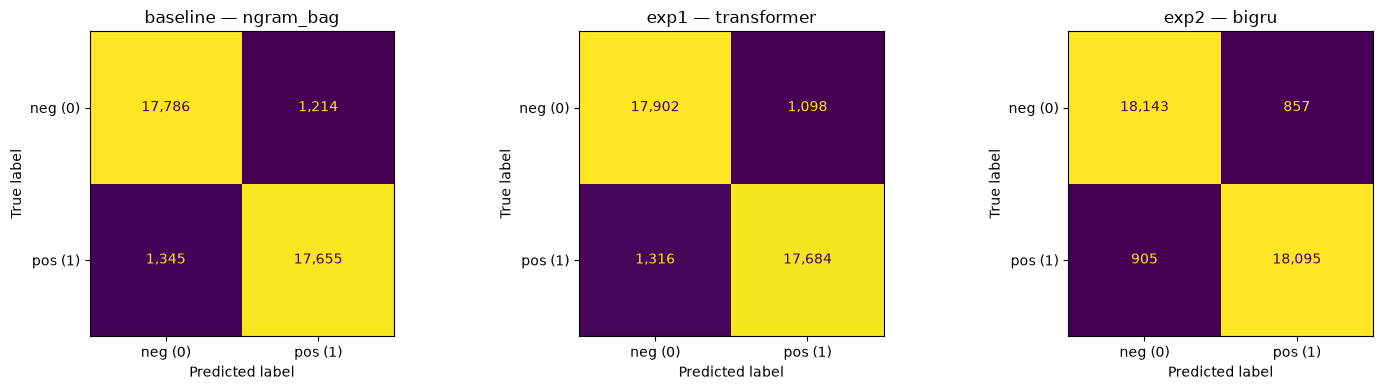

,tn,fp,fn,tp,FPR,FNR,total_errors
model,,,,,,,
baseline,17786,1214,1345,17655,0.0639,0.0708,2559
exp1,17902,1098,1316,17684,0.0578,0.0693,2414
exp2,18143,857,905,18095,0.0451,0.0476,1762


In [14]:
# ── 8.2 Confusion matrices (counts + rates) ──
fig, axes = plt.subplots(1, len(R), figsize=(5 * len(R), 4))
for ax, (name, r) in zip(np.atleast_1d(axes), R.iterrows()):
    cm = np.array([[r.tn, r.fp], [r.fn, r.tp]], dtype=int)
    skm.ConfusionMatrixDisplay(cm, display_labels=["neg (0)", "pos (1)"]).plot(ax=ax, colorbar=False, values_format=",d")
    ax.set_title(f"{name} — {r.arch}")
plt.tight_layout(); plt.savefig(OUT_DIR / "confusion_matrices_all.png", dpi=150); plt.show()
CM_TBL = R[["tn", "fp", "fn", "tp"]].astype(int)
CM_TBL["FPR"] = (CM_TBL.fp / (CM_TBL.fp + CM_TBL.tn)).round(4); CM_TBL["FNR"] = (CM_TBL.fn / (CM_TBL.fn + CM_TBL.tp)).round(4)
CM_TBL["total_errors"] = CM_TBL.fp + CM_TBL.fn; display(CM_TBL)

In [15]:
# ── 8.3 95% bootstrap confidence intervals ──
fmt = lambda t: f"[{t[0]:.4f}, {t[1]:.4f}]"
CI_TBL = pd.DataFrame({"accuracy": R["accuracy"].round(4), "accuracy 95% CI": R["accuracy_ci95"].map(fmt),
                       "macro-F1": R["f1_macro"].round(4), "macro-F1 95% CI": R["macro_f1_ci95"].map(fmt),
                       "MCC": R["mcc"].round(4), "MCC 95% CI": R["mcc_ci95"].map(fmt)})
print(f"Bootstrap resamples: {CFG['n_bootstrap']}, seed {SEED}"); display(CI_TBL)

Bootstrap resamples: 1000, seed 1446


,accuracy,accuracy 95% CI,macro-F1,macro-F1 95% CI,MCC,MCC 95% CI
model,,,,,,
baseline,0.9327,"[0.9301, 0.9351]",0.9327,"[0.9301, 0.9351]",0.8653,"[0.8603, 0.8703]"
exp1,0.9365,"[0.9341, 0.9388]",0.9365,"[0.9341, 0.9388]",0.8730,"[0.8683, 0.8777]"
exp2,0.9536,"[0.9514, 0.9557]",0.9536,"[0.9514, 0.9557]",0.9073,"[0.9028, 0.9114]"


In [16]:
# ── 8.4 Paired McNemar test: baseline vs. each experimental model ──
pre = "mcnemar_vs_baseline_"
MC_TBL = R.loc[R.index != "baseline", [c for c in R.columns if c.startswith(pre)]].copy()
MC_TBL.columns = [c[len(pre):] for c in MC_TBL.columns]
MC_TBL = MC_TBL.rename(columns={"b_base_right_exp_wrong": "b: baseline right, exp wrong", "c_base_wrong_exp_right": "c: baseline wrong, exp right"})
MC_TBL["accuracy_gain_vs_baseline"] = (R.loc[MC_TBL.index, "accuracy"] - R.loc["baseline", "accuracy"]).round(4)
MC_TBL["significant (α=0.05)"] = MC_TBL["p_value"] < 0.05
MC_TBL["p_value"] = MC_TBL["p_value"].map(lambda p: f"{p:.3e}")
display(MC_TBL)
print("H0: equal error rates. Only discordant pairs (b, c) matter; c > b means the experimental model fixes more baseline errors than it introduces.")

,"b: baseline right, exp wrong","c: baseline wrong, exp right",statistic,p_value,accuracy_gain_vs_baseline,significant (α=0.05)
model,,,,,,
exp1,766.0,911.0,12.364937,4.375e-04,0.0038,True
exp2,561.0,1358.0,330.180302,8.780e-74,0.0210,True


H0: equal error rates. Only discordant pairs (b, c) matter; c > b means the experimental model fixes more baseline errors than it introduces.


n  F1_baseline  F1_exp1  F1_exp2  err_baseline  err_exp1  err_exp2
slice         value                                                                           
has_contrast  False     15635       0.9420   0.9479   0.9599        0.0569    0.0512    0.0393
              True      22365       0.9245   0.9271   0.9482        0.0747    0.0722    0.0513
has_negation  False      9753       0.9239   0.9315   0.9389        0.0552    0.0500    0.0444
              True      28247       0.9259   0.9293   0.9513        0.0715    0.0682    0.0470
length_bucket Q1_short   9590       0.9293   0.9345   0.9473        0.0679    0.0632    0.0505
              Q2         9450       0.9329   0.9353   0.9571        0.0669    0.0646    0.0428
              Q3         9502       0.9335   0.9353   0.9564        0.0663    0.0645    0.0435
              Q4_long    9458       0.9280   0.9349   0.9487        0.0683    0.0619    0.0487
truncated     False     36157       0.9332   0.9368   0.9544        0.0668    0.0632    0.0456
              True       1843       0.9111   0.9219   0.9294        0.0787    0.0695    0.0624

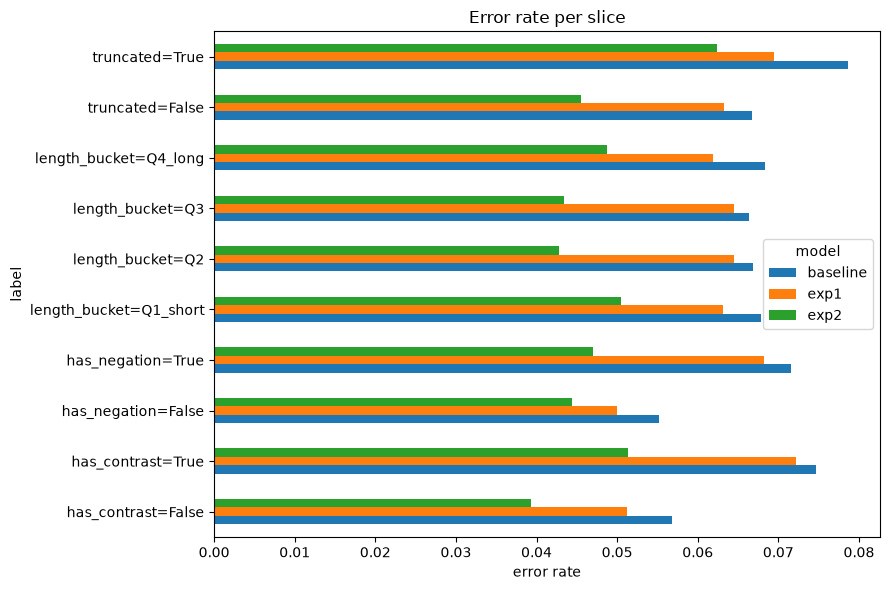

In [17]:
# ── 8.5 Robustness: macro-F1 AND error rate per slice ──
sl = SLICE_DF.pivot_table(index=["slice", "value"], columns="model", values=["n", "macro_f1", "error_rate"])
SLICE_TBL = pd.concat([sl["n"].iloc[:, 0].astype(int).rename("n"), sl["macro_f1"].add_prefix("F1_"), sl["error_rate"].add_prefix("err_")], axis=1).round(4)
display(SLICE_TBL)
er = SLICE_DF.assign(label=SLICE_DF["slice"] + "=" + SLICE_DF["value"]).pivot(index="label", columns="model", values="error_rate")
er.plot.barh(figsize=(9, 6)); plt.xlabel("error rate"); plt.title("Error rate per slice")
plt.tight_layout(); plt.savefig(OUT_DIR / "slice_error_rates.png", dpi=150); plt.show()

In [18]:
# ── 8.6 Cost, peak memory, and exact hardware per model ──
def _epochs_run(log_path):
    return sum(1 for r in read_log(log_path) if r.get("event") == "epoch")
EFF_TBL = R[["arch", "emb_dim", "lr", "batch_size", "dropout", "param_count", "train_time_min", "examples_per_sec", "peak_memory_mb"]].copy()
EFF_TBL["epochs_run"] = [_epochs_run(RESULTS[m]["log_path"]) for m in EFF_TBL.index]
EFF_TBL["best_val_macro_f1"] = R["best_val_macro_f1"].round(4)
EFF_TBL[["train_time_min", "examples_per_sec", "peak_memory_mb"]] = EFF_TBL[["train_time_min", "examples_per_sec", "peak_memory_mb"]].round(2)
display(EFF_TBL)
HW_TBL = pd.DataFrame({m: RESULTS[m]["hardware"] for m in RESULTS}).T
HW_TBL = HW_TBL[[c for c in ["gpu", "gpu_mem_gb", "cuda", "cpu", "cpu_count", "torch", "platform"] if c in HW_TBL]]
display(HW_TBL)

,arch,emb_dim,lr,batch_size,dropout,param_count,train_time_min,examples_per_sec,peak_memory_mb,epochs_run,best_val_macro_f1
model,,,,,,,,,,,
baseline,ngram_bag,64,0.0020,256,0.2,15732417,0.55,80405.30,354.74,5,0.9312
exp1,transformer,128,0.0005,128,0.1,6154113,2.97,14949.53,946.88,5,0.9348
exp2,bigru,128,0.0010,128,0.3,6063362,11.99,3698.26,439.63,5,0.9527


,gpu,gpu_mem_gb,cuda,cpu,cpu_count,torch,platform
baseline,NVIDIA GeForce RTX 4090,25.76,12.6,AMD Ryzen 9 7950X 16-Core Processor,32,2.14.1+cu126,Windows-11-10.0.26200-SP0
exp1,NVIDIA GeForce RTX 4090,25.76,12.6,AMD Ryzen 9 7950X 16-Core Processor,32,2.14.1+cu126,Windows-11-10.0.26200-SP0
exp2,NVIDIA GeForce RTX 4090,25.76,12.6,AMD Ryzen 9 7950X 16-Core Processor,32,2.14.1+cu126,Windows-11-10.0.26200-SP0


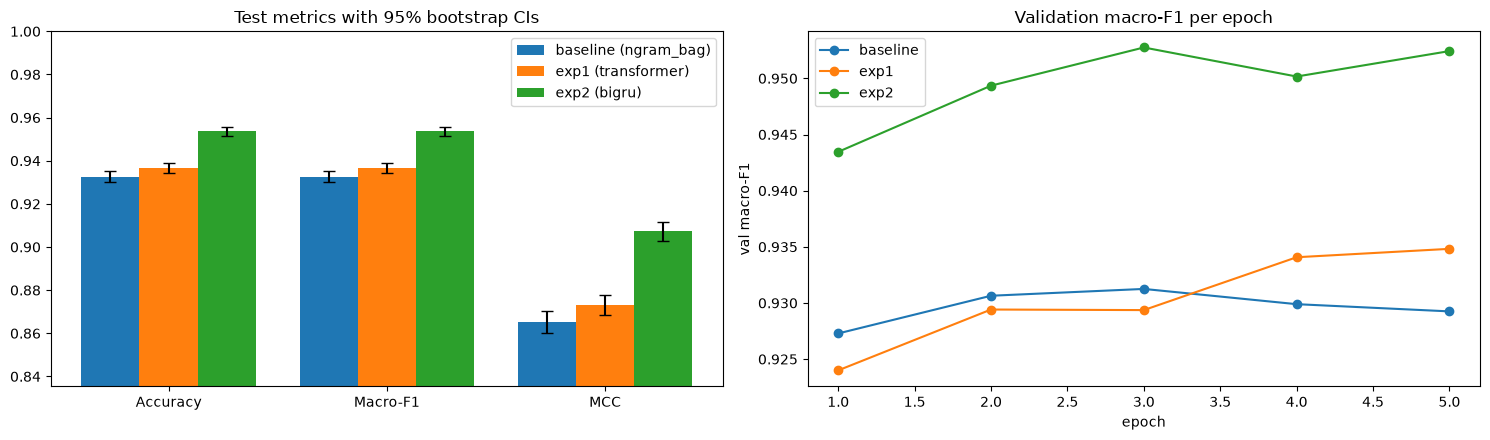

Tables saved to task2_sentiment\tejas\outputs


In [19]:
# ── 8.7 Comparison plot + save all tables ──
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
mets = [("accuracy", "accuracy_ci95"), ("f1_macro", "macro_f1_ci95"), ("mcc", "mcc_ci95")]
x = np.arange(len(mets)); w = 0.8 / len(R)
for i, (name, r) in enumerate(R.iterrows()):
    vals = [r[m] for m, _ in mets]
    err = np.array([[r[m] - r[c][0], r[c][1] - r[m]] for m, c in mets]).T
    ax[0].bar(x + i * w, vals, w, yerr=err, capsize=4, label=f"{name} ({r.arch})")
ax[0].set_xticks(x + w * (len(R) - 1) / 2, ["Accuracy", "Macro-F1", "MCC"])
ax[0].set_ylim(min(R["mcc"]) - 0.03, 1.0); ax[0].legend(); ax[0].set_title("Test metrics with 95% bootstrap CIs")
for name in RESULTS:
    ep = [r for r in read_log(RESULTS[name]["log_path"]) if r.get("event") == "epoch"]
    ax[1].plot([r["epoch"] + 1 for r in ep], [r["val_macro_f1"] for r in ep], "o-", label=name)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val macro-F1"); ax[1].set_title("Validation macro-F1 per epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "model_comparison.png", dpi=150); plt.show()
for fname, df in {"table_full_metrics": FULL_TBL, "table_confusion": CM_TBL, "table_bootstrap_ci": CI_TBL, "table_mcnemar": MC_TBL,
                  "table_slices": SLICE_TBL, "table_efficiency": EFF_TBL, "table_hardware": HW_TBL}.items():
    df.to_csv(OUT_DIR / f"{fname}.csv")
    try:
        (OUT_DIR / f"{fname}.md").write_text(df.to_markdown(), encoding="utf-8")
    except ImportError:
        pass
print("Tables saved to", OUT_DIR.relative_to(REPO_ROOT))

In [20]:
# ── 8.8 Consolidated metrics_report.csv: every required Task 2 metric, one row per model ──
rep_df = R.copy()
for c in ["accuracy_ci95", "macro_f1_ci95", "mcc_ci95"]:
    rep_df[c + "_low"] = rep_df[c].map(lambda t: t[0]); rep_df[c + "_high"] = rep_df[c].map(lambda t: t[1]); rep_df = rep_df.drop(columns=c)
sw = SLICE_DF.assign(key=SLICE_DF["slice"] + "=" + SLICE_DF["value"].astype(str))
for met in ("macro_f1", "error_rate"):
    rep_df = rep_df.join(sw.pivot(index="model", columns="key", values=met).add_prefix(f"slice_{met}__"))
rep_df["gpu"] = [RESULTS[m]["hardware"].get("gpu") for m in rep_df.index]
rep_df["cpu"] = [f'{RESULTS[m]["hardware"]["cpu"]} ({RESULTS[m]["hardware"]["cpu_count"]} cores)' for m in rep_df.index]
rep_df["epochs_run"] = EFF_TBL["epochs_run"]
rep_df["test_n"], rep_df["n_bootstrap"], rep_df["seed"] = len(Y_TEST), CFG["n_bootstrap"], SEED
rep_df = rep_df.reset_index()
rep_df.to_csv(MEMBER_DIR / "metrics_report.csv", index=False)
print(f"metrics_report.csv -> {(MEMBER_DIR / 'metrics_report.csv').relative_to(REPO_ROOT)}  ({rep_df.shape[0]} models × {rep_df.shape[1]} columns)")
display(rep_df.T)

metrics_report.csv -> task2_sentiment\tejas\metrics_report.csv  (3 models × 77 columns)


,0,1,2
model,baseline,exp1,exp2
member,tejas,tejas,tejas
emb_dim,64,128,128
lr,0.002,0.0005,0.001
batch_size,256,128,128
...,...,...,...
cpu,AMD Ryzen 9 7950X 16-Core Processor (32 cores),AMD Ryzen 9 7950X 16-Core Processor (32 cores),AMD Ryzen 9 7950X 16-Core Processor (32 cores)
epochs_run,5,5,5
test_n,38000,38000,38000
n_bootstrap,1000,1000,1000


### Interpretation templates (fill in after the run, in your own words, in `results.md`)
- **Ranking:** [model] > [model] > [model] on accuracy / macro-F1 / MCC; McNemar p = [..] → [significant / not].
- **Micro-F1 = accuracy** for single-label binary; **weighted-F1 = macro-F1** because the test set is exactly balanced.
- **Calibration:** ECE [..] / Brier [..] — [which model is best calibrated and why].
- **Slices:** contrast words, negation, truncated/long reviews — [which model is most robust; order-aware vs. bigram-bag].
- **Cost:** params dominated by embedding tables ([..]); examples/sec [..] — [accuracy gained per unit of training time].
- **vs. Shriram's models:** [team comparison — same preprocessing + evaluation code, different model families].